# Week 6: [주제 입력] 실습 (2026-05-06)

## 1. 환경 설정

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier, VotingRegressor, StackingClassifier, StackingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, r2_score, mean_absolute_error, precision_recall_curve, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from imblearn.ensemble import BalancedRandomForestClassifier
from config import CONTENT_DIR

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'NanumGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False



In [ ]:
data = pd.read_csv(f'{CONTENT_DIR}/train_data.csv')
data.drop('subject', axis=1, inplace=True)

data.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Data columns (total 562 columns):
 #    Column                                Non-Null Count  Dtype  
---   ------                                --------------  -----  
 0    tBodyAcc-mean()-X                     5881 non-null   float64
 1    tBodyAcc-mean()-Y                     5881 non-null   float64
 2    tBodyAcc-mean()-Z                     5881 non-null   float64
 3    tBodyAcc-std()-X                      5881 non-null   float64
 4    tBodyAcc-std()-Y                      5881 non-null   float64
 5    tBodyAcc-std()-Z                      5881 non-null   float64
 6    tBodyAcc-mad()-X                      5881 non-null   float64
 7    tBodyAcc-mad()-Y                      5881 non-null   float64
 8    tBodyAcc-mad()-Z                      5881 non-null   float64
 9    tBodyAcc-max()-X                      5881 non-null   float64
 10   tBodyAcc-max()-Y                      5881 non-null   float64
 11   tBodyAcc-max(

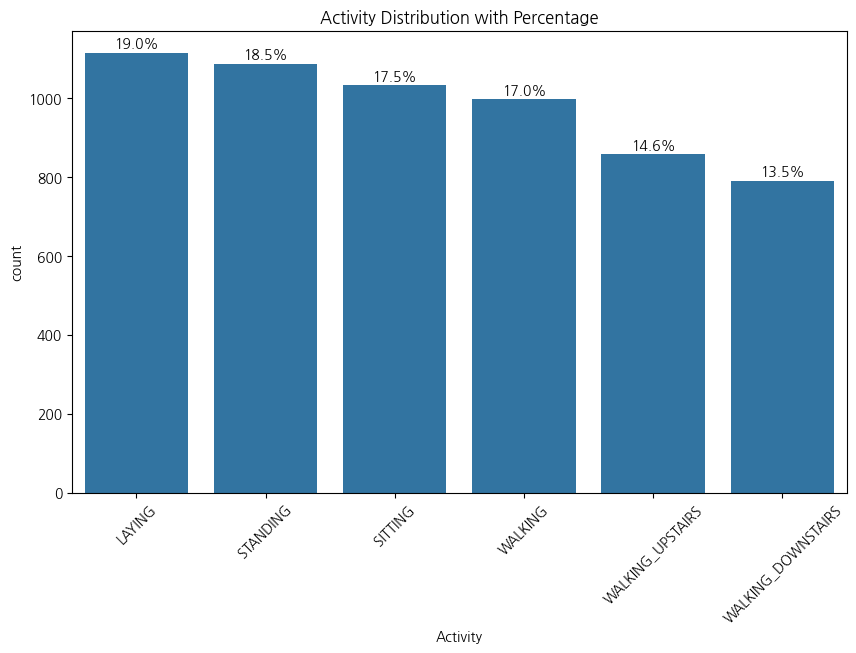

In [20]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=data, x='Activity', order=data['Activity'].value_counts().index)

# 각 막대 위에 비율(%) 표시
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 5
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('Activity Distribution with Percentage')
plt.xticks(rotation=45)
plt.show()


In [ ]:
features = pd.read_csv(f'{CONTENT_DIR}/features.csv')

target = 'Activity'

X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=2026)

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(f'name={rf_model.__class__.__name__}')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
c = cross_val_score( rf_model, X_train, y_train, cv=10, scoring="accuracy")
print(f"평균 : {c.mean():0.4f}")
print(f"표준편차 : {c.std():0.5f}")
print('='*70)

name=RandomForestClassifier
[[330   0   0   0   0   0]
 [  0 280  15   0   0   0]
 [  0  21 309   0   0   0]
 [  0   0   0 297   3   3]
 [  0   0   0   2 232   2]
 [  0   0   0   2   0 269]]
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       330
           SITTING       0.93      0.95      0.94       295
          STANDING       0.95      0.94      0.94       330
           WALKING       0.99      0.98      0.98       303
WALKING_DOWNSTAIRS       0.99      0.98      0.99       236
  WALKING_UPSTAIRS       0.98      0.99      0.99       271

          accuracy                           0.97      1765
         macro avg       0.97      0.97      0.97      1765
      weighted avg       0.97      0.97      0.97      1765

평균 : 0.9757
표준편차 : 0.00728


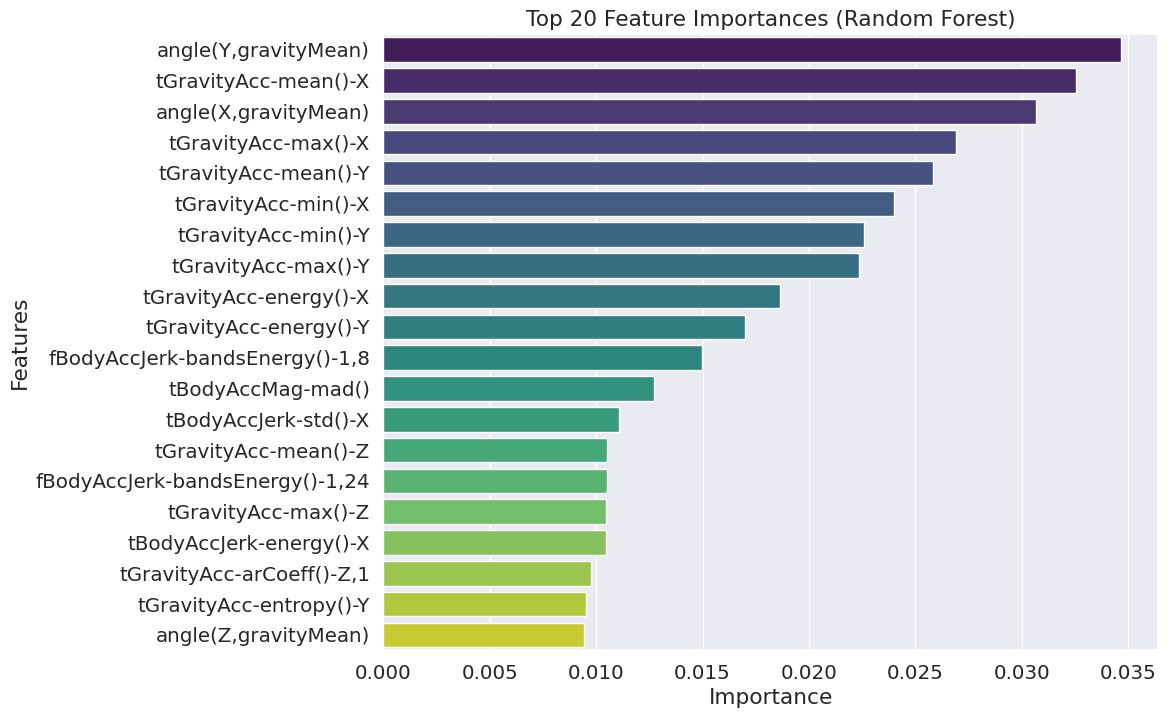

In [55]:
importance_data = pd.DataFrame()

importance_data['feature_name'] = X.columns
importance_data['feature_importance'] = rf_model.feature_importances_
importance_sort = importance_data.sort_values(by='feature_importance', ascending=False)

# 상위 20개 변수 추출
top_n = 20
bottom_n = 20
importance_top_n = importance_sort.head(top_n)
importance_bottom_n = importance_sort.tail(bottom_n)

# 수평 막대 그래프 시각화
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_top_n, x='feature_importance', y='feature_name', palette='viridis')

# 그래프 서식 설정
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


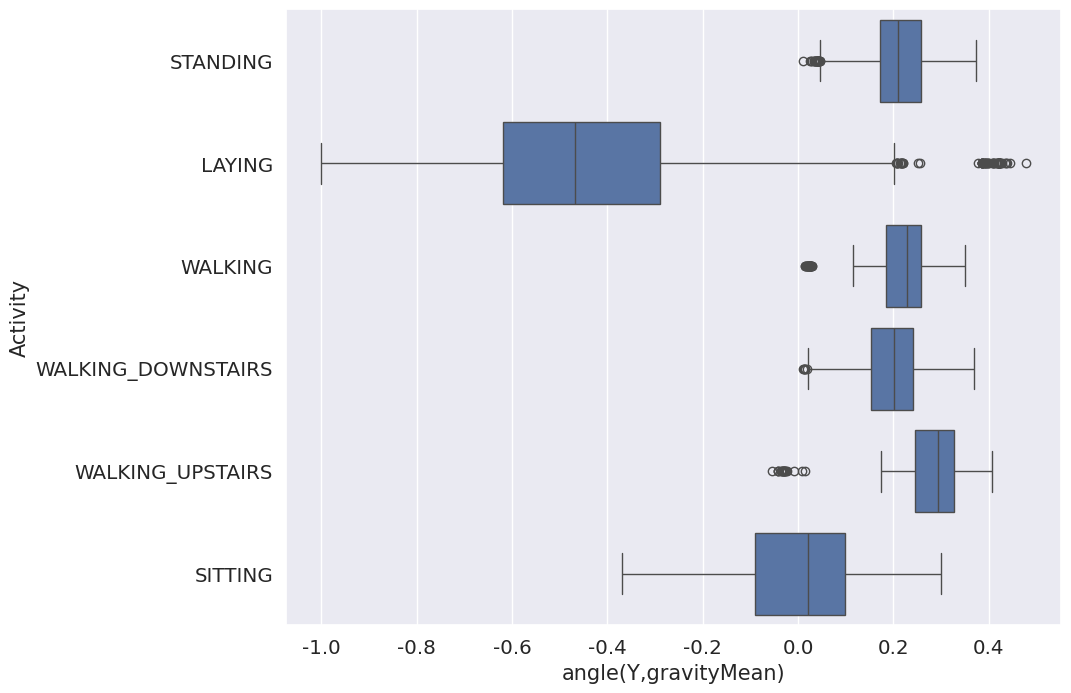

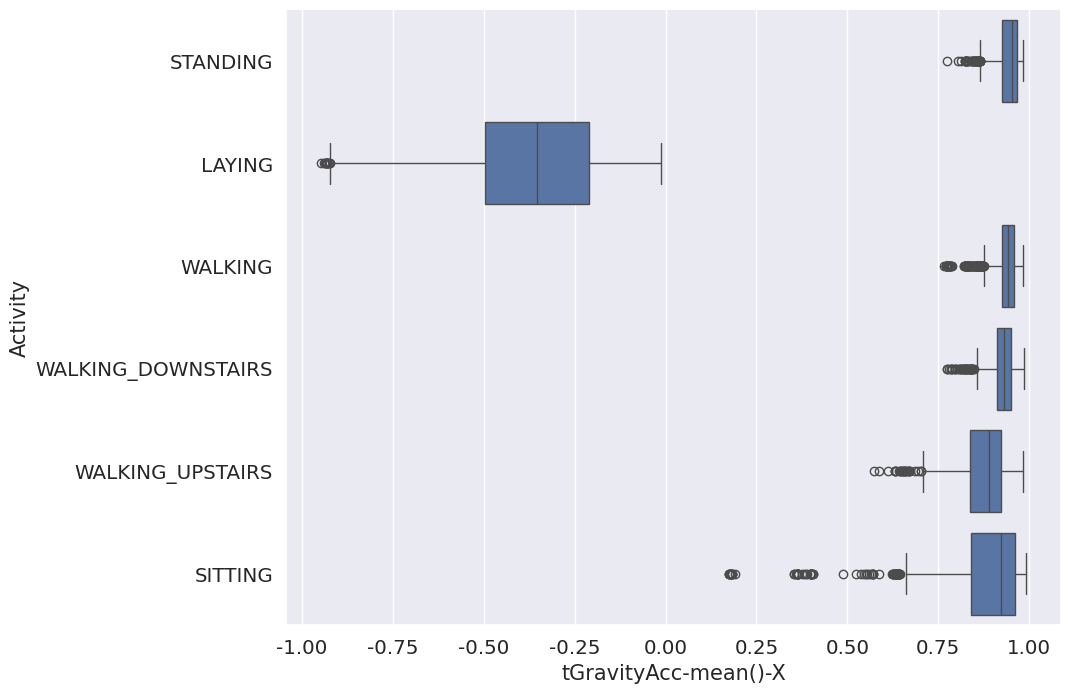

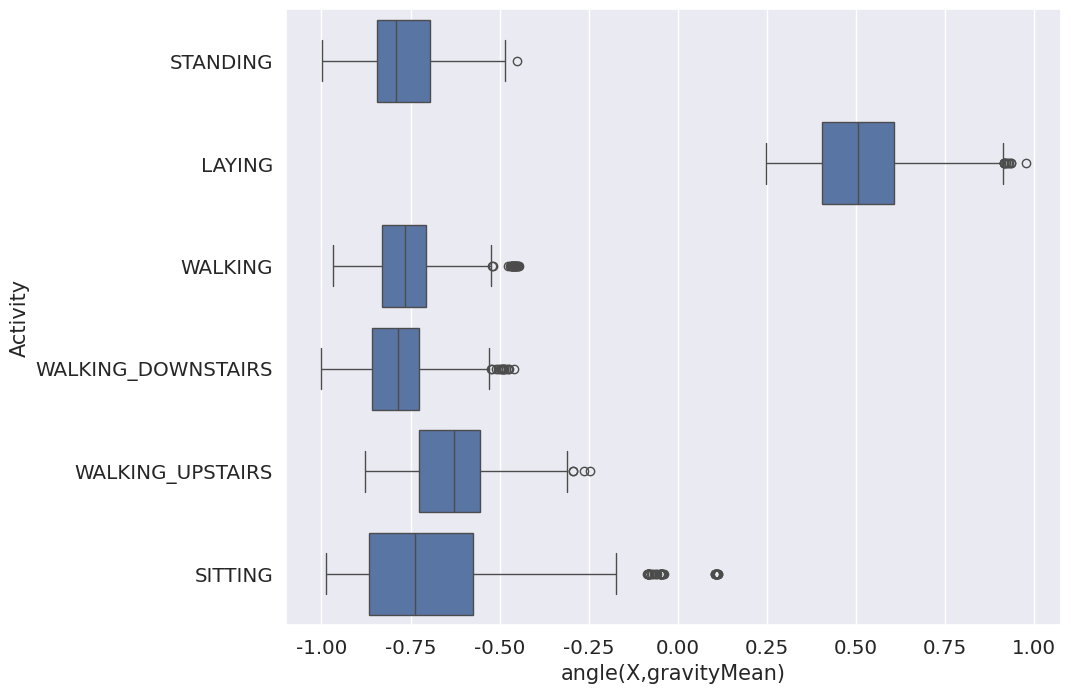

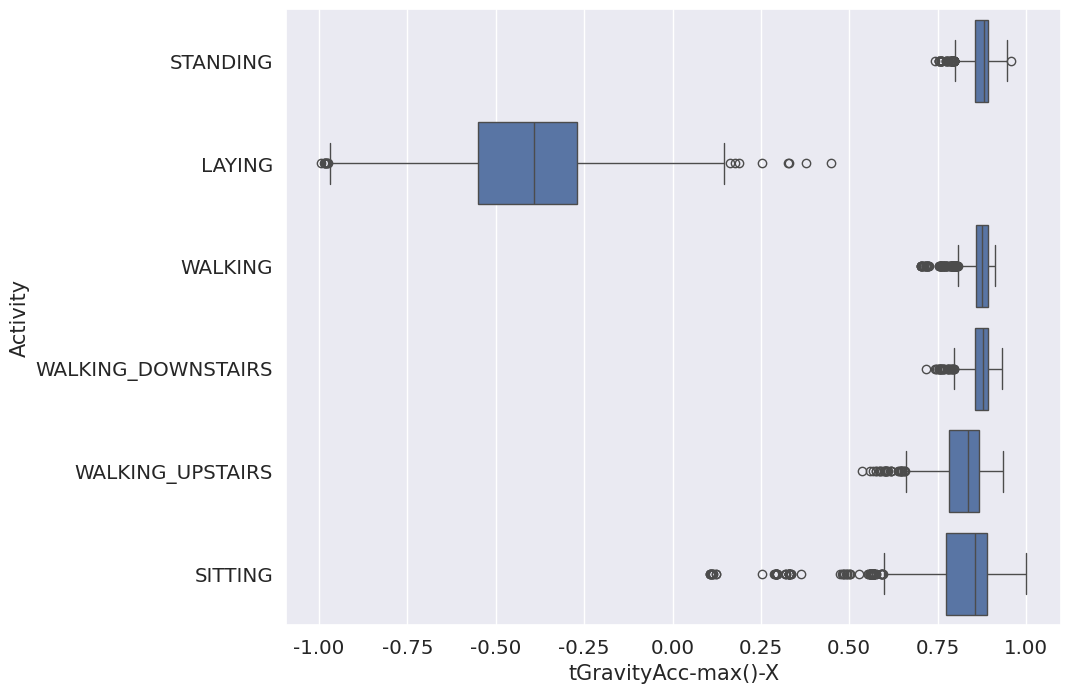

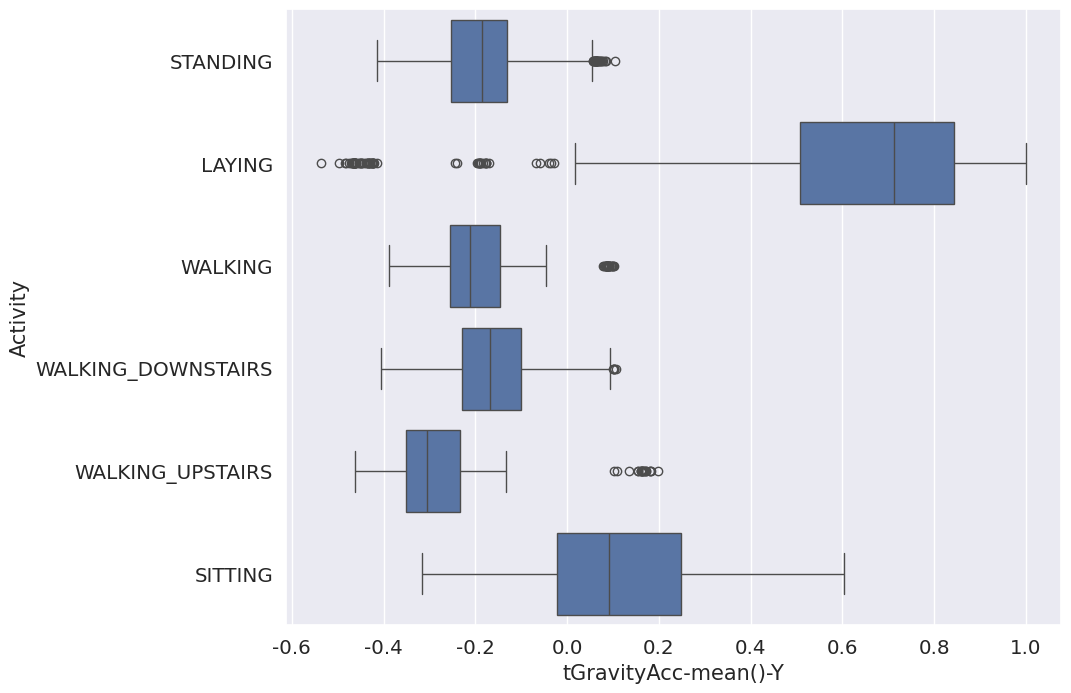

In [59]:
for i in range(5):
    plt.figure(figsize=(10,8))
    sns.set(font_scale=1.3)
    f_name = importance_top_n.iloc[i, 0]
    sns.boxplot(x=f_name, y='Activity', data=data)
    plt.xlabel(f_name, fontsize=15)
    plt.ylabel('Activity', fontsize=15)
    plt.show()

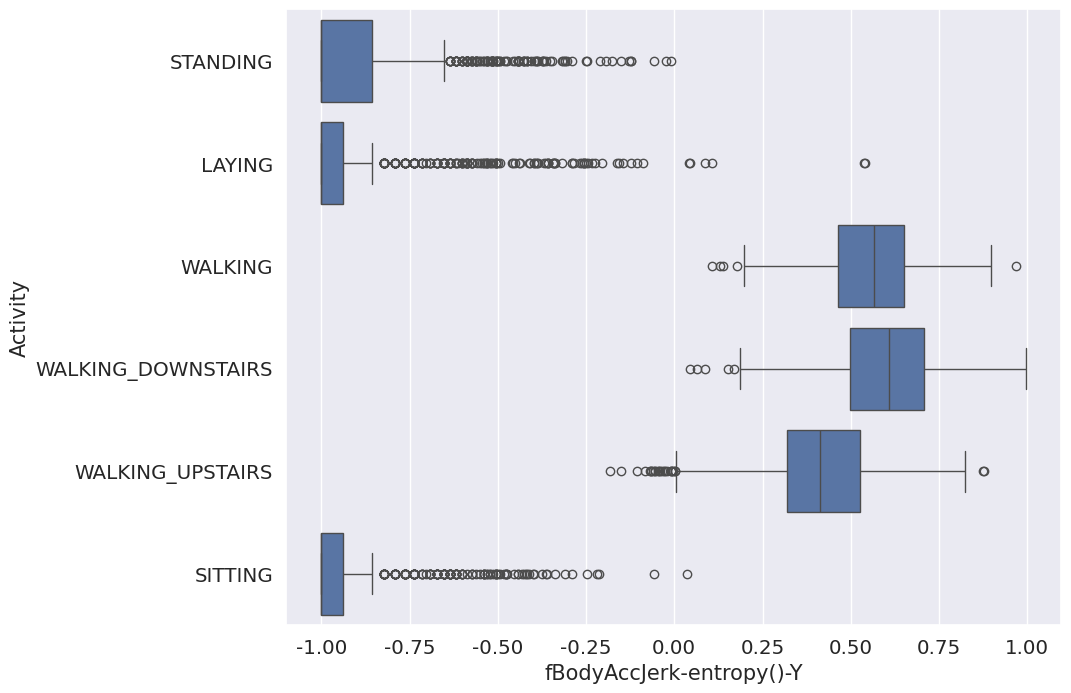

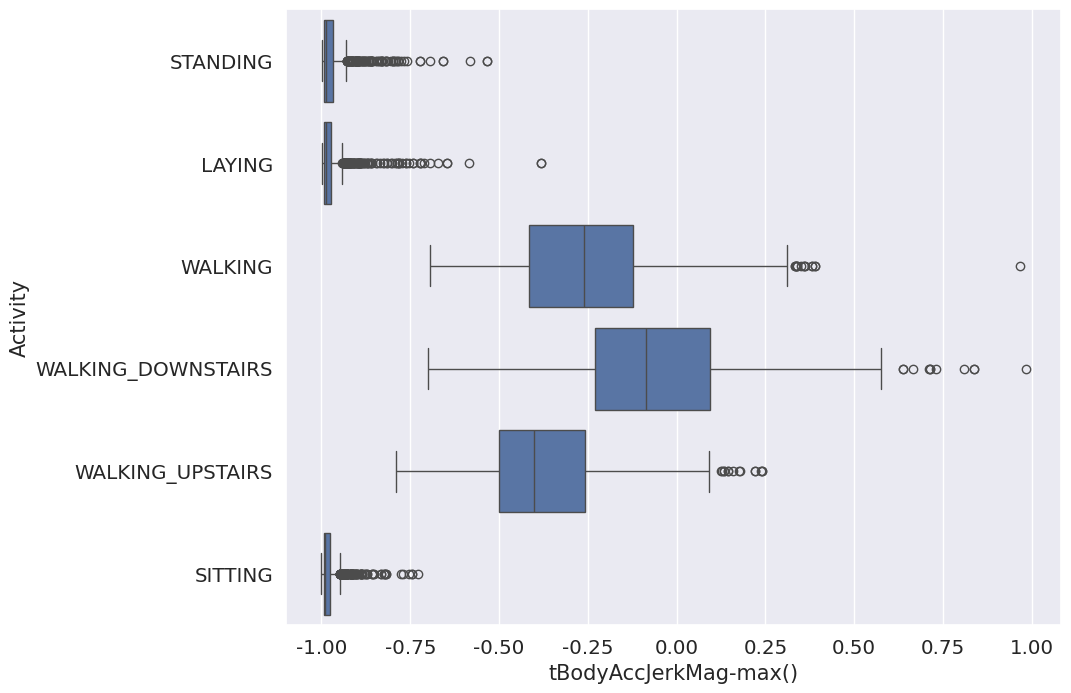

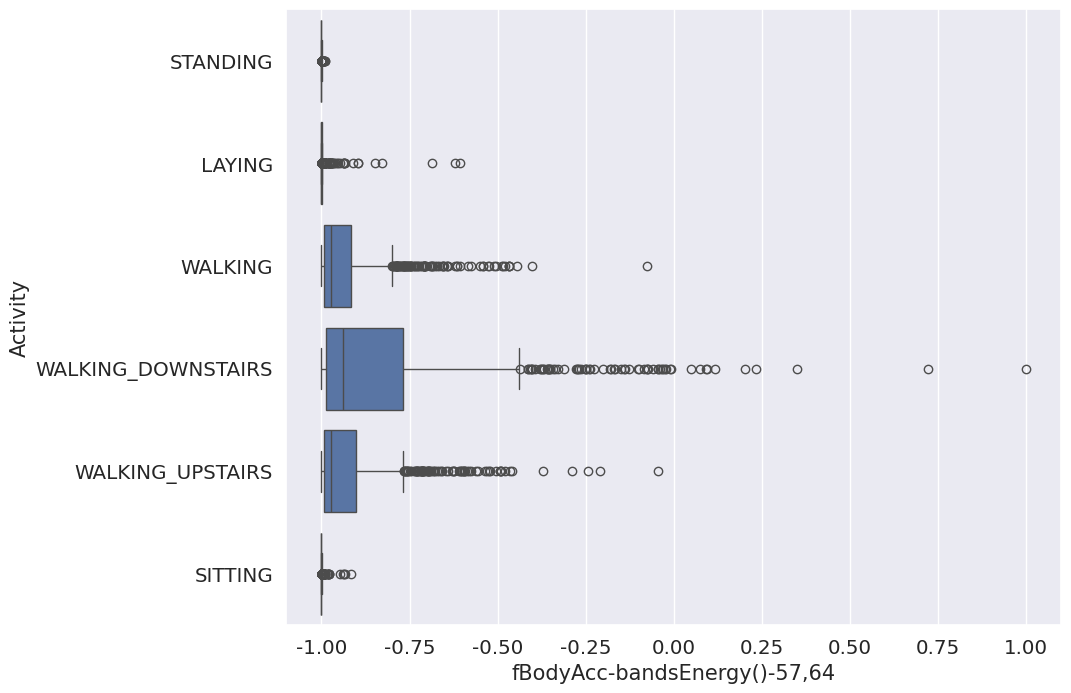

In [60]:
for i in [1,2,3]:
    plt.figure(figsize=(10,8))
    sns.set(font_scale=1.3)
    f_name = importance_bottom_n.iloc[-i, 0]
    sns.boxplot(x=f_name, y='Activity', data=data)
    plt.xlabel(f_name, fontsize=15)
    plt.ylabel('Activity', fontsize=15)
    plt.show()

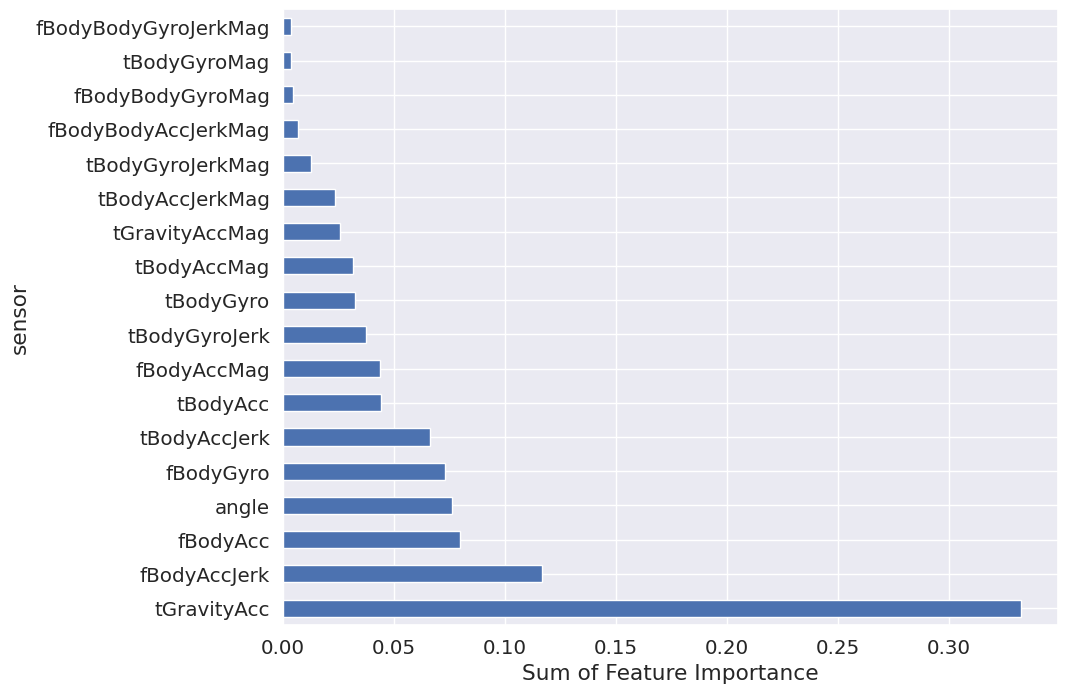

In [70]:
merge_df = features.merge(importance_sort)

sensor_sum = merge_df.groupby('sensor')['feature_importance'].sum().sort_values(ascending=False)

sensor_sum.plot.barh(figsize=(10, 8))
plt.xlabel('Sum of Feature Importance')
plt.show()

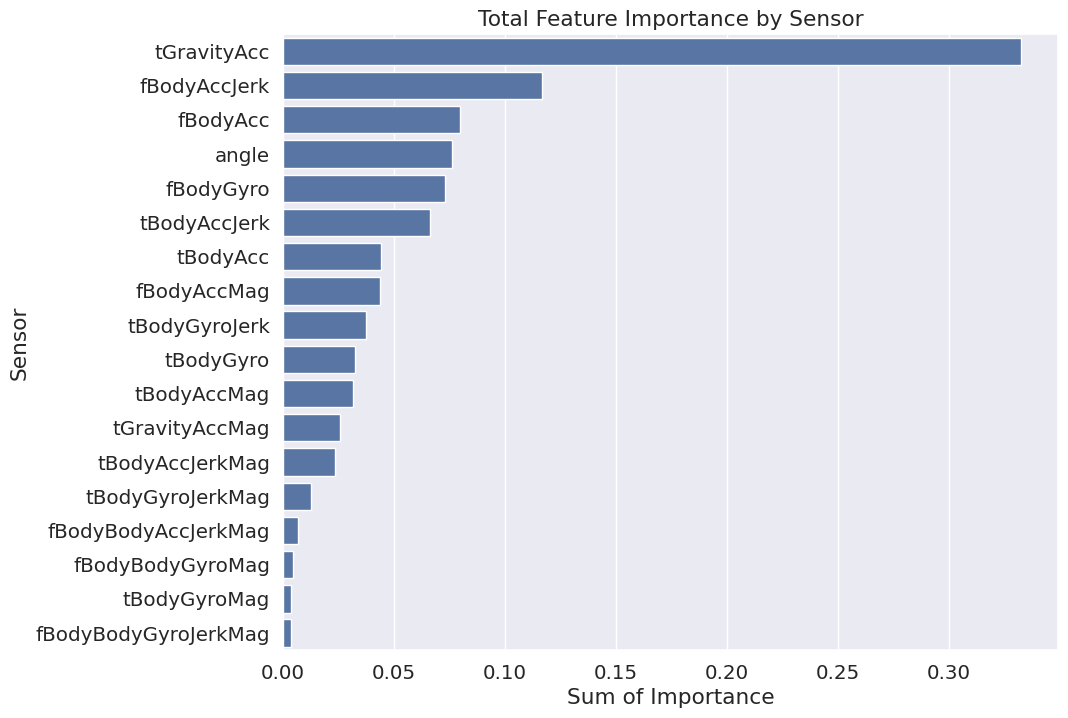

In [71]:

plt.figure(figsize=(10, 8))
sns.barplot(x=sensor_sum.values, y=sensor_sum.index)
plt.title('Total Feature Importance by Sensor')
plt.xlabel('Sum of Importance')
plt.ylabel('Sensor')
plt.show()

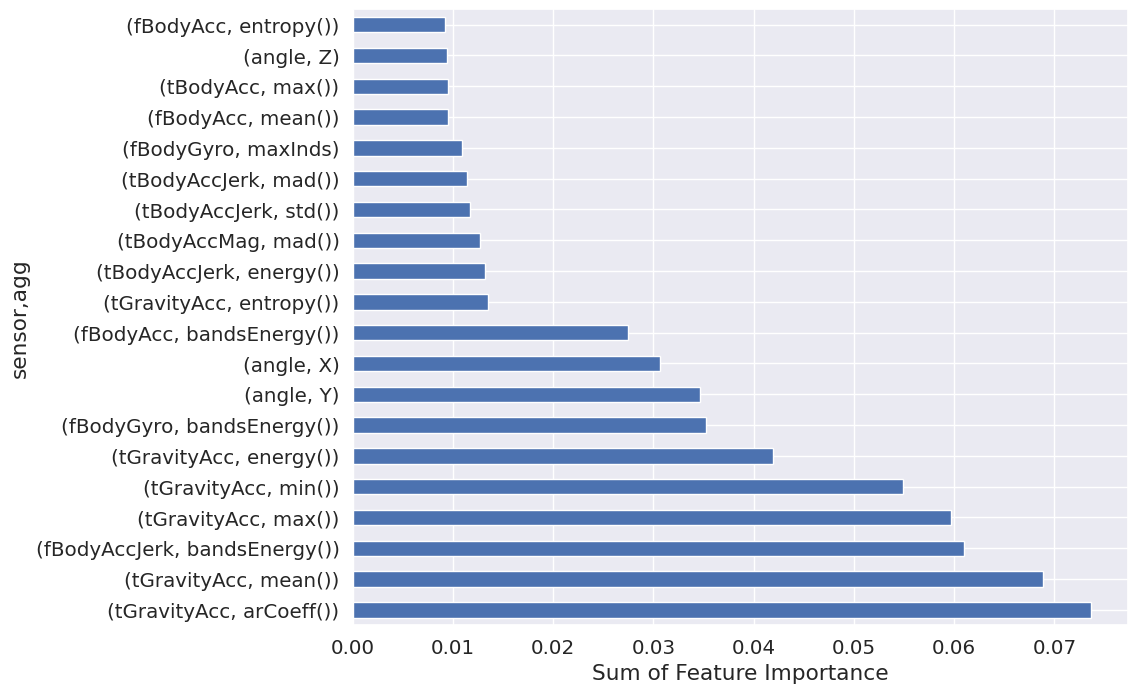

In [80]:
sensor_agg_sum = merge_df.groupby(['sensor', 'agg'])['feature_importance'].sum().sort_values(ascending=False)

sensor_agg_sum.head(20).plot.barh(figsize=(10, 8))
plt.xlabel('Sum of Feature Importance')
plt.show()

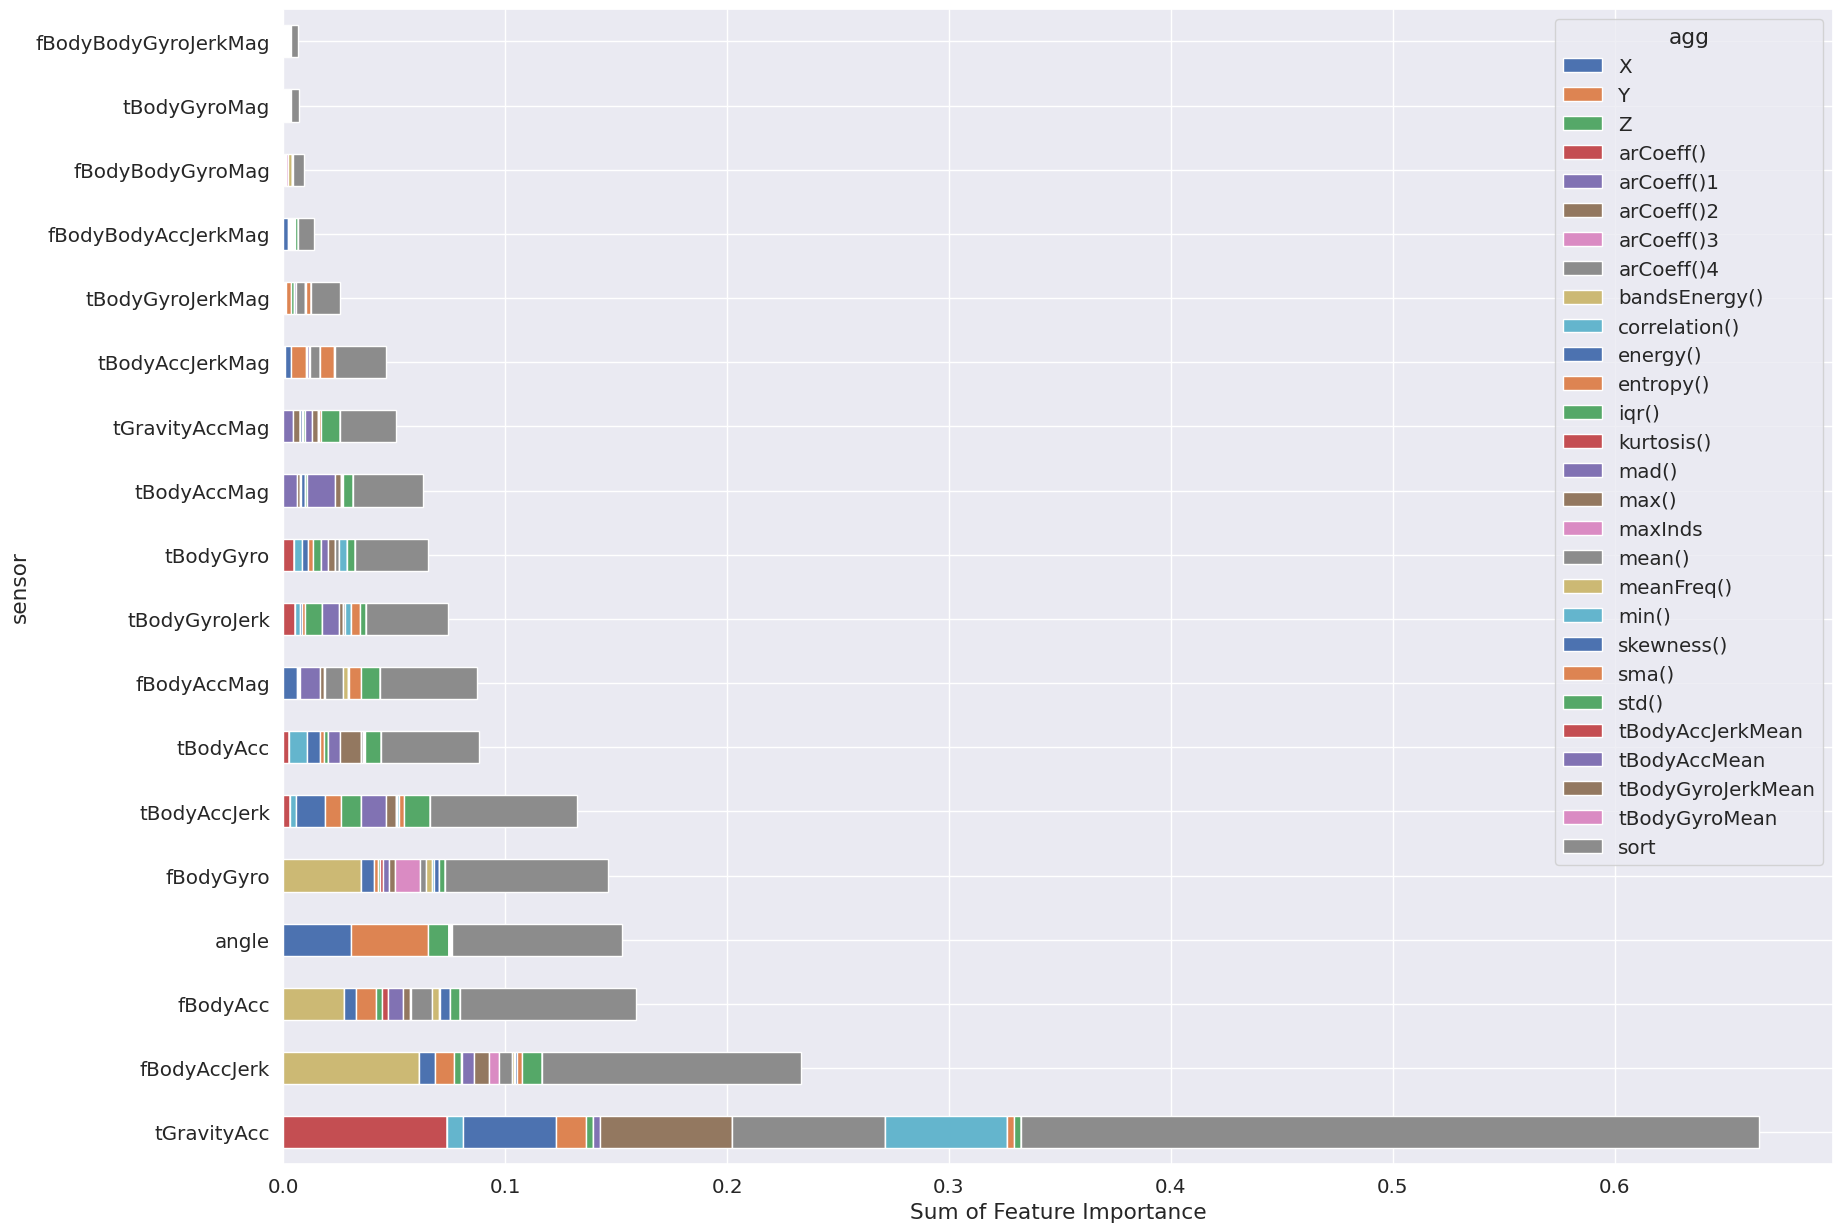

In [ ]:
acc = sensor_agg_sum.unstack('agg')

acc['sort'] = acc.sum(axis=1)
acc.sort_values(by='sort', ascending=False, inplace=True)

acc.plot(kind='barh', stacked=True, figsize=(20,15))
plt.xlabel('Sum of agg')
plt.show()

In [97]:
target = 'Activity'

X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=2026)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

result = pd.DataFrame(columns=['data', 'model_name', 'accuracy_score', 'f1_score'])

def matrix_c(model, X_train, y_train, X_test, y_test, data_name='train'):
     # 1. 모델 학습 및 예측
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # 2. 성능 지표 계산
    acc = accuracy_score(y_test, y_pred)
    # 멀티 클래스 분류이므로 average='macro' 또는 'weighted'를 사용해야 합니다.
    f1 = f1_score(y_test, y_pred, average='macro') 
    model_name = model.__class__.__name__
    
    # 3. 콘솔 출력 (기존 로직 유지)
    print(f'Data: {data_name}, Model: {model_name}')
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    
    # 4. 데이터프레임에 한 줄로 추가할 수 있도록 리스트로 반환
    return [data_name, model_name, acc, f1]
model_knn = KNeighborsClassifier(n_neighbors=3)
model_lg = LogisticRegression()
model_svc = SVC()
model_xgb = XGBClassifier()
model_gbc = GradientBoostingClassifier()

result.loc[len(result)]= matrix_c(model_knn, X_train_s, y_train, X_test_s, y_test)
result.loc[len(result)]= matrix_c(model_lg, X_train, y_train, X_test, y_test)
result.loc[len(result)]= matrix_c(model_svc, X_train, y_train, X_test, y_test)
result.loc[len(result)]= matrix_c(model_xgb, X_train, y_train_encoded, X_test, y_test_encoded)
result.loc[len(result)]= matrix_c(model_gbc, X_train, y_train, X_test, y_test)

result

Data: train, Model: KNeighborsClassifier
[[330   0   0   0   0   0]
 [  2 259  34   0   0   0]
 [  0  26 304   0   0   0]
 [  0   0   0 302   1   0]
 [  0   0   0   1 233   2]
 [  0   0   0   1   0 270]]
                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       330
           SITTING       0.91      0.88      0.89       295
          STANDING       0.90      0.92      0.91       330
           WALKING       0.99      1.00      1.00       303
WALKING_DOWNSTAIRS       1.00      0.99      0.99       236
  WALKING_UPSTAIRS       0.99      1.00      0.99       271

          accuracy                           0.96      1765
         macro avg       0.96      0.96      0.96      1765
      weighted avg       0.96      0.96      0.96      1765

Data: train, Model: LogisticRegression
[[330   0   0   0   0   0]
 [  2 277  16   0   0   0]
 [  0  14 316   0   0   0]
 [  0   0   0 301   1   1]
 [  0   0   0   1 232   3]
 [  0   0   0   0  

,data,model_name,accuracy_score,f1_score
0,train,KNeighborsClassifier,0.962040,0.963547
1,train,LogisticRegression,0.978470,0.979018
2,train,SVC,0.969405,0.970494
3,train,XGBClassifier,0.986969,0.987267
4,train,GradientBoostingClassifier,0.981303,0.982153


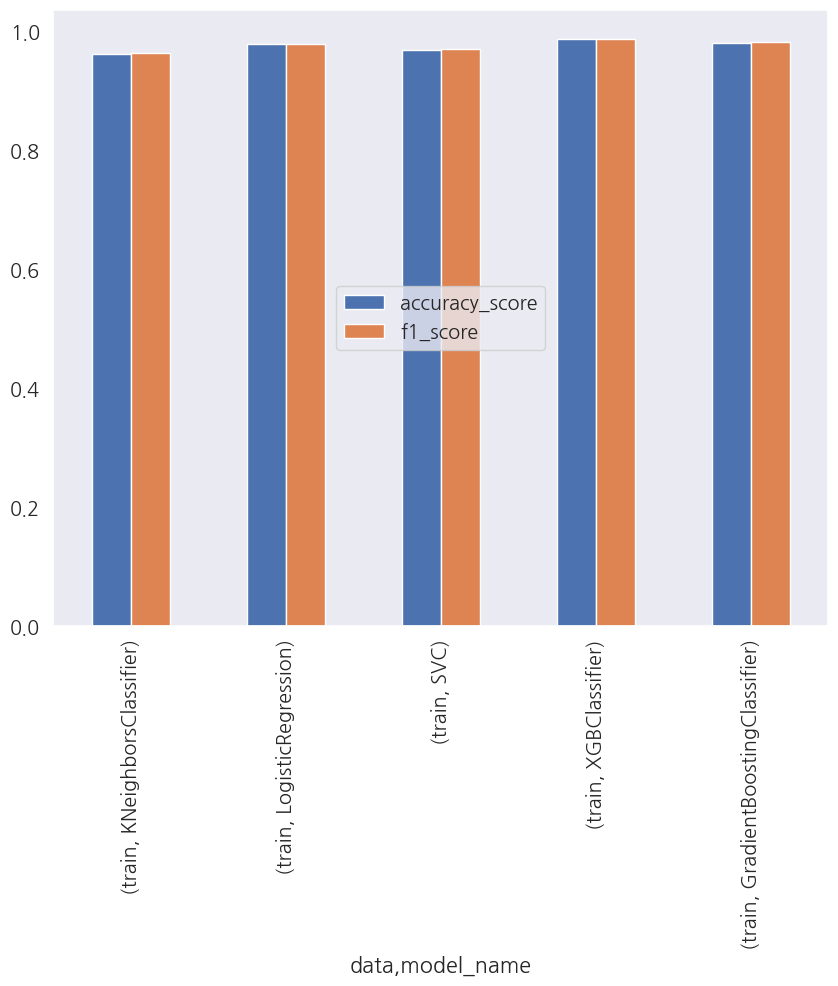

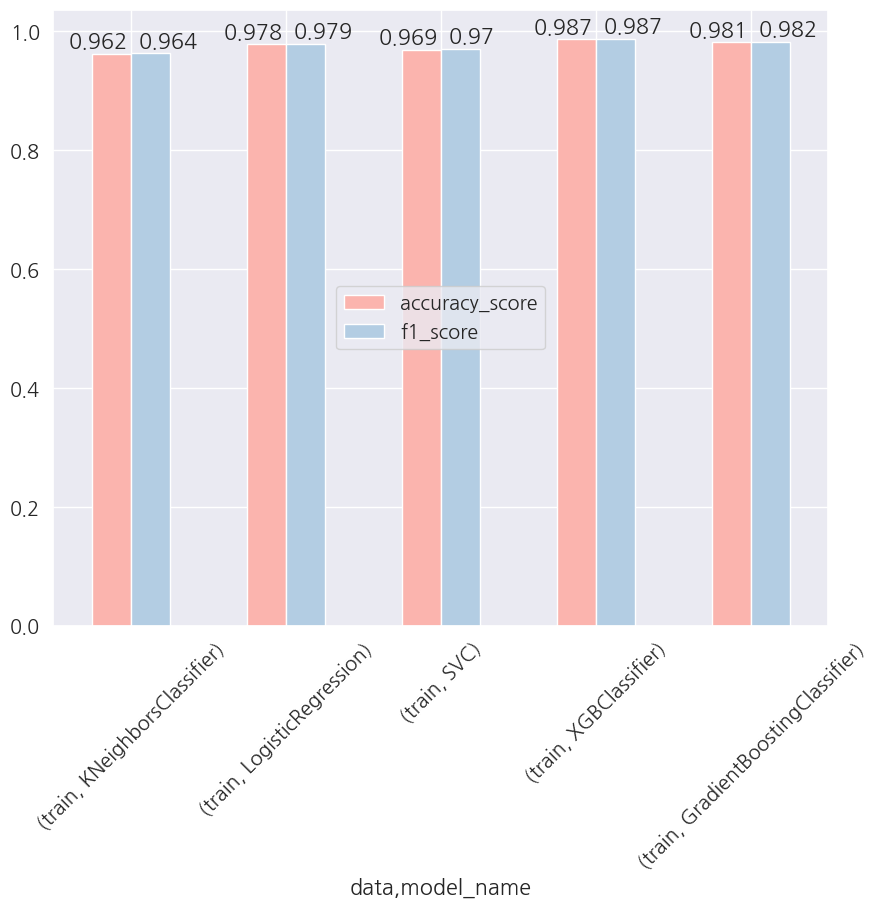

In [98]:
result_comp = result.set_index(['data','model_name'])
plt.rcParams["figure.figsize"] = (10,8)
result_comp.plot(kind='bar')
plt.grid()
plt.legend(loc='center')
plt.show()

colors = sns.color_palette('Pastel1')

result_comp.plot(color=colors,kind='bar',zorder=2)
for i in range(0,5) :
    plt.text(i-0.4,result.loc[i, 'accuracy_score']+0.02, str(round(result.loc[i, 'accuracy_score'], 3)), va='center')
    plt.text(i+0.05,result.loc[i, 'f1_score']+0.02, str(round(result.loc[i, 'f1_score'], 3)), va='center')
plt.xticks(rotation=45)
plt.grid(zorder=1)
plt.legend(loc='center')
plt.show()

In [100]:
import optuna

def objective(trial):
    # 하이퍼파라미터 탐색 범위 지정
    param = {
        'max_depth': trial.suggest_int('max_depth', 2, 4),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'tree_method': 'hist',  # 학습 속도 향상
        'random_state': 2026,
    }
    model = XGBClassifier(**param)
    
    # 교차 검증을 통해 성능 측정 (여기서는 accuracy 기준)
    # y 데이터는 앞에서 인코딩한 y_train_encoded를 사용해야 합니다.
    score = cross_val_score(model, X_train, y_train_encoded, cv=3, scoring='accuracy').mean()
    
    return score

study = optuna.create_study(direction='maximize')
# 2. 최적화 수행 (n_trials는 시도 횟수입니다. 데이터가 크면 시간을 고려해 조절하세요.)
study.optimize(objective, n_trials=20)

# 최적의 파라미터로 모델 생성
best_model = XGBClassifier(**study.best_params, random_state=2026)
# 앞서 만든 matrix_c 함수로 최종 평가 및 결과 저장
result.loc[len(result)] = matrix_c(best_model, X_train, y_train_encoded, X_test, y_test_encoded, 'XGB_Tuned')

[I 2026-05-06 10:52:40,077] A new study created in memory with name: no-name-ae60aa24-e341-453c-abbc-a9fbeb3f55ba
[I 2026-05-06 10:53:07,096] Trial 0 finished with value: 0.9844509232264333 and parameters: {'max_depth': 3, 'learning_rate': 0.20377261836368993}. Best is trial 0 with value: 0.9844509232264333.
[I 2026-05-06 10:53:27,169] Trial 1 finished with value: 0.9448493683187561 and parameters: {'max_depth': 2, 'learning_rate': 0.039783430438881294}. Best is trial 0 with value: 0.9844509232264333.
[I 2026-05-06 10:53:54,196] Trial 2 finished with value: 0.9834791059280855 and parameters: {'max_depth': 3, 'learning_rate': 0.15487233137175763}. Best is trial 0 with value: 0.9844509232264333.
[I 2026-05-06 10:54:14,316] Trial 3 finished with value: 0.9295432458697764 and parameters: {'max_depth': 2, 'learning_rate': 0.013267818988253386}. Best is trial 0 with value: 0.9844509232264333.
[I 2026-05-06 10:54:45,102] Trial 4 finished with value: 0.9477648202137998 and parameters: {'max_de

Data: XGB_Tuned, Model: XGBClassifier
[[330   0   0   0   0   0]
 [  0 286   9   0   0   0]
 [  0  15 315   0   0   0]
 [  0   0   0 303   0   0]
 [  0   0   0   1 235   0]
 [  0   0   0   0   0 271]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       330
           1       0.95      0.97      0.96       295
           2       0.97      0.95      0.96       330
           3       1.00      1.00      1.00       303
           4       1.00      1.00      1.00       236
           5       1.00      1.00      1.00       271

    accuracy                           0.99      1765
   macro avg       0.99      0.99      0.99      1765
weighted avg       0.99      0.99      0.99      1765



In [139]:
importance_sort_best = pd.DataFrame()
importance_sort_best['feature_name'] = X_train.columns
importance_sort_best['feature_importance'] = best_model.feature_importances_

importance_sort_best.sort_values(by='feature_importance', ascending=False, inplace=True)
importance_sort_best = importance_sort_best.reset_index(drop=True)


for i in [95,50]:
    importance_95 = importance_sort_best['feature_name'].loc[:i+1]

    X_train_95 = X_train[importance_95]
    X_test_95 = X_test[importance_95]

    importance_95_model = XGBClassifier(**study.best_params, random_state=2026)
    result.loc[len(result)] = matrix_c(importance_95_model, X_train_95, y_train_encoded, X_test_95, y_test_encoded, f'XGB_importance_{i}')


Data: XGB_importance_95, Model: XGBClassifier
[[330   0   0   0   0   0]
 [  0 291   4   0   0   0]
 [  0  14 316   0   0   0]
 [  0   0   0 302   0   1]
 [  0   0   0   1 234   1]
 [  0   0   0   1   1 269]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       330
           1       0.95      0.99      0.97       295
           2       0.99      0.96      0.97       330
           3       0.99      1.00      1.00       303
           4       1.00      0.99      0.99       236
           5       0.99      0.99      0.99       271

    accuracy                           0.99      1765
   macro avg       0.99      0.99      0.99      1765
weighted avg       0.99      0.99      0.99      1765

Data: XGB_importance_50, Model: XGBClassifier
[[330   0   0   0   0   0]
 [  0 290   5   0   0   0]
 [  0  16 314   0   0   0]
 [  0   0   2 298   2   1]
 [  0   0   0   1 234   1]
 [  0   0   0   1   1 269]]
              precision    recall  f1-s

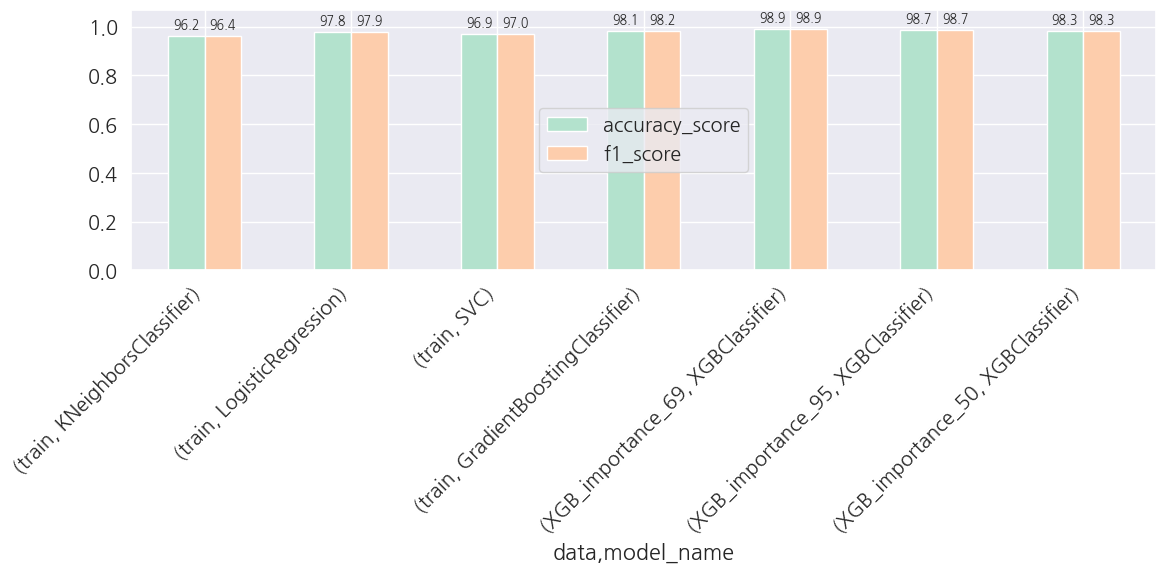

In [140]:
result_comp = result.set_index(['data','model_name'])

colors = sns.color_palette('Pastel2', n_colors=len(result_comp.columns))

ax = result_comp.plot(color=colors, kind='bar', zorder=2, figsize=(12,6))

for container in ax.containers:
    labels = [f'{bar.get_height() * 100:.1f}' for bar in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(1.05, result_comp.to_numpy().max() + 0.08))
plt.grid(axis='y', zorder=1)
plt.legend(loc='center')
plt.tight_layout()
plt.show()